# Exam

> Data: **2026-01-08**
>
> Autore: **Luigi Malaguti**

##

---

## Parte 0: Il Dataset

Preso da [Kaggle](https://www.kaggle.com/datasets/uciml/adult-census-income), il dataset Bank Marketing è scaricabile attraverso il [link](https://bit.ly/4sjlIjQ) e contiene dati demografici e lavorativi di cittadini statunitensi, come età, istruzione, occupazione, stato civile, ore lavorate a settimana e capitale investito. L'obiettivo è predire se il reddito annuale di una persona supera i 50.000$, indicato dalla colonna target income (>50K / ≤50K).

### Imports

In [1]:
# !curl -sLo dataset.zip "https://link"
# !unzip -o dataset.zip
# !mv file.csv dataset.csv
FILE_ID = "1OH-hOTYNWlanXRhd_zjSuyMIg-l-kF5P"
!curl -sLo dataset.csv "https://drive.google.com/uc?export=download&id={FILE_ID}"

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import ExtraTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import Normalizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest

### Dataset

In [3]:
df = pd.read_csv("dataset.csv")

#### Overview

In [4]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


#### Instances

In [6]:
df.shape

(32561, 15)

#### Missing values

In [7]:
df.isnull().sum().sum()

np.int64(0)

#### Balancing

In [8]:
df["income"].value_counts()

,count
income,
<=50K,24720
>50K,7841


<Axes: >

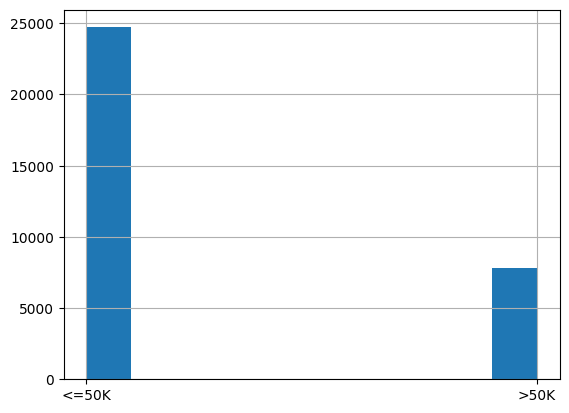

In [9]:
df["income"].hist()

##

---

## Parte 1: Analisi (Punti 10)

### Domanda 01 (Punti 1)

Quante sono le istanze contenute nel dataset? Il dataset è completo (cioè per ogni istanza tutti i valori di ogni attributo sono sempre correttamente specificati - non esistono "missing values")? Il dataset è bilanciato per quanto riguarda la classe da predire?

In [10]:
df.shape[0]

32561

> Il dataset contiene 32561 istanze.

In [11]:
df.isnull().sum().sum()

np.int64(0)

> Si, il dataset risulta completo, in quanto non sono presenti missing values.

In [12]:
df["income"].value_counts()

,count
income,
<=50K,24720
>50K,7841


> No, il dataset non risulta essere bilanciato rispetto l'attributo `income`, in quanto sono presenti molte più istanze della classe `<=50K` rispetto alla classe `>50K`.

---

### Domanda 02 (Punti 2)

Verificare se i lavoratori con laurea (Bachelors, Masters, Doctorate) e età inferiore a 40 anni hanno una probabilità maggiore di reddito >50K rispetto ai lavoratori più anziani con lo stesso livello di istruzione.

In [13]:
df["income"] = df["income"].map({"<=50K": 0, ">50K": 1})

In [14]:
mask_education = df["education"].isin(["Bachelors", "Masters", "Doctorate"])
age_bins = pd.cut(df["age"], bins=[0, 39, np.inf])
pd.pivot_table(df[mask_education], index=age_bins, columns=mask_education, values="income", aggfunc="mean", observed=False)

education,True
age,
"(0.0, 39.0]",0.343725
"(39.0, inf]",0.587480


> No, sembrerebbe che i lavoratori con età superiore ai 40 anni abbiano più probabilità di avere un reddito maggiore a 50K rispetto ai lavoratori con età inferiore.

---

### Domanda 03 (Punti 3)

Discretizzare la variabile hours.per.week in 3 fasce (≤30, 31-50, >50). Creare una tabella pivot che mostri la percentuale di redditi >50K per fascia oraria e genere (sex). Chi lavora più ore ha sempre un reddito più alto? Ci sono disparità tra uomini e donne?

In [15]:
hours_per_week_bins = pd.cut(df["hours.per.week"], bins=[0, 30, 50, np.inf])
pd.pivot_table(df, index=hours_per_week_bins, columns="sex", values="income", aggfunc="mean", observed=False)

sex,Female,Male
hours.per.week,,
"(0.0, 30.0]",0.060228,0.074941
"(30.0, 50.0]",0.120240,0.314060
"(50.0, inf]",0.204263,0.450974


> Si, sembrerebbe che più ore si lavorino, più la probabilità di percepire un reddito maggiore a 50K aumenti. Inoltre, è possibile notare come ci sia un aumento differente rispetto ai due generi, la probabilità per l'uomo risulta maggiore rispetto a quella per la donna di percepire un reddito maggiore ai 50K.

---

### Domanda 04 (Punti 4)

Analizzare la relazione tra capitale investito (capital.gain) e livello di reddito: confrontare media e mediana di capital-gain per le due classi di reddito e visualizzare in un boxplot la distribuzione dei valori di capital.gain sulle due classi.

In [16]:
df.groupby("income")["capital.gain"].mean()

,capital.gain
income,
0,148.752468
1,4006.142456


In [17]:
df.groupby("income")["capital.gain"].median()

,capital.gain
income,
0,0.0
1,0.0


,0
capital.gain,"Axes(0.125,0.11;0.775x0.77)"


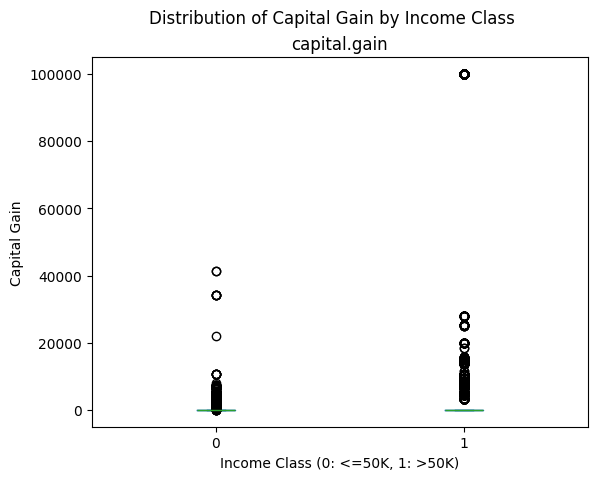

In [18]:
title = "Distribution of Capital Gain by Income Class"
xlabel = "Income Class (0: <=50K, 1: >50K)"
ylabel = "Capital Gain"
df.plot(kind="box", column="capital.gain", by="income", title=title, xlabel=xlabel, ylabel=ylabel)

##

---

## Parte 2: Trasformazione e Predizione (Punti 20)

### Domanda 01 (Punti 4)

Si vuole predire la classe di reddito (`income`). Ricaricare il dataset originale, eliminare eventuali attributi inutili (giustificare la scelta), eliminare le istanze che contengono valori nulli, eliminare eventuali righe duplicate, trasformare opportunamente i valori categorici e dividere il dataset in train (3/4 del dataset) e test (1/4), preservando le proporzioni delle classi nella colonna target. Confrontare la predizione ottenuta sia sul dataset train sia sul dataset test dai classificatori ExtraTreeClassifier, KNeighborsClassifier e da un dummy classifier a scelta. Effettuare alcune considerazioni sui risultati ottenuti, tenendo in considerazione i valori di F1 e della confusion matrix.

In [19]:
df = pd.read_csv("dataset.csv")
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

> Non è stato necessario rimuovere alcun attributo al fine della predizione, in quanto hanno informazioni riguardo la predizione.

In [20]:
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, dtype=int)
categorical_columns = df.select_dtypes(include="object").columns
df[categorical_columns] = encoder.fit_transform(df[categorical_columns])

In [21]:
X, y = df.drop("income", axis=1), df["income"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, stratify=y, random_state=0)

In [22]:
models = {
    "ExtraTree": ExtraTreeClassifier(random_state=0),
    "KNeighbors": KNeighborsClassifier(),
    "Dummy": DummyClassifier(strategy="most_frequent", random_state=0)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    print(name)
    print("=" * 30)
    print("TRAIN")
    print("    Accuracy:", accuracy_score(y_train, y_pred_train))
    print("    F1-score:", f1_score(y_train, y_pred_train))
    print(confusion_matrix(y_train, y_pred_train))
    print("-" * 30)
    print("TEST")
    print("    Accuracy:", accuracy_score(y_test, y_pred_test))
    print("    F1-score:", f1_score(y_test, y_pred_test))
    print(confusion_matrix(y_test, y_pred_test))
    print("=" * 30)
    print()

ExtraTree
TRAIN
    Accuracy: 0.9999590197524793
    F1-score: 0.999914944288509
[[18523     0]
 [    1  5878]]
------------------------------
TEST
    Accuracy: 0.8015980331899201
    F1-score: 0.5861538461538461
[[5378  797]
 [ 817 1143]]

KNeighbors
TRAIN
    Accuracy: 0.8348086222440784
    F1-score: 0.5682767484202634
[[17718   805]
 [ 3226  2653]]
------------------------------
TEST
    Accuracy: 0.7687768899815611
    F1-score: 0.39303000968054214
[[5645  530]
 [1351  609]]

Dummy
TRAIN
    Accuracy: 0.7590771248258339
    F1-score: 0.0
[[18523     0]
 [ 5879     0]]
------------------------------
TEST
    Accuracy: 0.7590657652120467
    F1-score: 0.0
[[6175    0]
 [1960    0]]



> L'accuracy per il modello `ExtraTree` risulta dell'80% sul dataset di test, mentre per il modello `KNeighbors` risulta essere del 76%, risultati abbastanza buoni. Le F1, a differenza dell'accuracy, non risultano molto buone, rispettivamente del 58% e 39%. Infatti, possiamo notare che nella confusion matrix per quest'ultimo modello, gli errori nella predizione risultano essere molto sbilanciate. Il modello predice molte volte la classe 1 come classe 0, molte più volte rispetto all'altra classe.
>
> Il modello `Dummy`, invece, è stato addestrato per predire sempre a priori la classe più frequente, questo è il motivo dell'accuracy di 75%, ma sono predizioni non veritiere.

---

### Domanda 02 (Punti 4)

Verificare, nelle predizioni sul dataset di test ottenute dal classificatore ExtraTreeClassifier, se la probabilità di reddito >50K predetta per gli uomini è diversa da quella predetta per le donne. Valutare se l'accuratezza di predizione ottenuta eliminando la colonna `sex` è diversa. Cosa si può osservare da questa valutazione?

In [23]:
extra_tree = models["ExtraTree"]
y_pred = extra_tree.predict(X_test)

In [24]:
mask_female = X_test["sex"] == 0
mask_male = X_test["sex"] == 1
mask_g_50k = y_pred == 1

probability_g_50k_female = y_pred[mask_female & mask_g_50k].shape[0] / y_pred[mask_female].shape[0]
probability_g_50k_male = y_pred[mask_male & mask_g_50k].shape[0] / y_pred[mask_male].shape[0]

print("Probability of income >50K for females:", probability_g_50k_female)
print("Probability of income >50K for males:", probability_g_50k_male)

ratio = probability_g_50k_female / probability_g_50k_male if probability_g_50k_female < probability_g_50k_male else probability_g_50k_male / probability_g_50k_female
print("Ratio:", ratio)

Probability of income >50K for females: 0.10944363103953147
Probability of income >50K for males: 0.3037201554691838
Ratio: 0.360343655397068


In [25]:
X_test["sex"].value_counts()

,count
sex,
1,5403
0,2732


> Si, le due probabilità risultano differenti. Questo può essere dovuto dal fatto che ci sia uno sbilanciamento tra il genere delle persone. Infatti, il numero di donne con un `income` >50K risultano essere solamente 2732, contro i 5403 degli uomini. Infatti il ratio risulta molto basso.

In [26]:
X, y = df.drop(["income", "sex"], axis=1), df["income"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, stratify=y, random_state=0)

In [27]:
extra_tree.fit(X_train, y_train)
y_pred_train = extra_tree.predict(X_train)
y_pred_test = extra_tree.predict(X_test)

print("ExtraTree")
print("=" * 30)
print("TRAIN")
print("    Accuracy:", accuracy_score(y_train, y_pred_train))
print("    F1-score:", f1_score(y_train, y_pred_train))
print(confusion_matrix(y_train, y_pred_train))
print("-" * 30)
print("TEST")
print("    Accuracy:", accuracy_score(y_test, y_pred_test))
print("    F1-score:", f1_score(y_test, y_pred_test))
print(confusion_matrix(y_test, y_pred_test))
print("=" * 30)
print()

ExtraTree
TRAIN
    Accuracy: 0.9999590197524793
    F1-score: 0.999914944288509
[[18523     0]
 [    1  5878]]
------------------------------
TEST
    Accuracy: 0.8003687768899815
    F1-score: 0.591343734272773
[[5336  839]
 [ 785 1175]]



> I valori di accuracy e F1 per il modello `ExtraTree` su questo nuovo dataset in assenza di `sex` rimangono pressoché invariati sul dataset di test. Questo vuole dire che l'attributo `sex` non è così rilevante al fine della predizione.

---

### Domanda 03 (Punti 2)

A partire dal dataset utilizzato al punto 1, trovare i valori migliori dei parametri `criterion` e `max_depth` del classificatore ExtraTreeClassifier. Come variano le performance?

In [28]:
X, y = df.drop("income", axis=1), df["income"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, stratify=y, random_state=0)

In [29]:
params = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [None, 1, 2, 3, 4, 5],
}
grid_search = GridSearchCV(
    estimator=extra_tree,
    param_grid=params,
)
grid_search.fit(X_train, y_train)
y_pred = grid_search.predict(X_test)
print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Best parameters: {'criterion': 'entropy', 'max_depth': None}
Best score: 0.7980901353861242
Accuracy: 0.8044253226797787
F1-score: 0.5877170251360456
[[5410  765]
 [ 826 1134]]


> Attraverso il `GridSearch` abbiamo trovato i parametri ottimali per il modello `ExtraTree`, ovvero `criterion: entropy` e `max_depth: None`. I valori di accuracy e di F1 su questo modello con parametri ottimali risultano essere molto in linea con quelle viste al primo punto, non variano in modo rilevante.

---

### Domanda 04 (Punti 3)

Creare una pipeline in cui, a partire dal dataset utilizzato al punto 1, i valori degli attributi `age` e `hours.per. week` sono discretizzati in 5 intervalli, le variabili `capital.gain` e `capital.loss` sono scalate nell'intervallo 0-1 e tutti gli altri attributi sono lasciati invariati. Applicare il classificatore ExtraTreeClassifier con i valori migliori dei parametri analizzati nel punto 3 e confrontare i risultati.

In [30]:
X, y = df.drop("income", axis=1), df["income"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, stratify=y, random_state=0)

In [31]:
discretizer = KBinsDiscretizer(n_bins=5, random_state=0)
scaler = Normalizer()

column_transformer = ColumnTransformer(
    transformers=[
        ("discretizer", discretizer, ["age", "hours.per.week"]),
        ("scaler", scaler, ["capital.gain", "capital.loss"]),
    ],
    remainder="passthrough",
    force_int_remainder_cols=False,
)
column_transformer

ColumnTransformer(force_int_remainder_cols=False, remainder='passthrough',
                  transformers=[('discretizer',
                                 KBinsDiscretizer(random_state=0),
                                 ['age', 'hours.per.week']),
                                ('scaler', Normalizer(),
                                 ['capital.gain', 'capital.loss'])])

In [32]:
best_criterion = grid_search.best_params_["criterion"]
best_max_depth = grid_search.best_params_["max_depth"]
extra_tree = ExtraTreeClassifier(criterion=best_criterion, max_depth=best_max_depth, random_state=0)

pipeline = Pipeline(
    steps=[
        ("column_transformer", column_transformer),
        ("extra_tree", extra_tree),
    ],
)
pipeline

Pipeline(steps=[('column_transformer',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('discretizer',
                                                  KBinsDiscretizer(random_state=0),
                                                  ['age', 'hours.per.week']),
                                                 ('scaler', Normalizer(),
                                                  ['capital.gain',
                                                   'capital.loss'])])),
                ('extra_tree',
                 ExtraTreeClassifier(criterion='entropy', random_state=0))])

In [33]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7822987092808851
F1-score: 0.5571392848212053
[[5250  925]
 [ 846 1114]]


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(


> Rispetto a quanto visto nei punti precedenti, i valori di accuracy e F1 per questa pipeline risultano leggermente inferiori ai precedenti, anche se solamente di un paio di punti percentuali.

---

### Domanda 05 (Punti 3)

Creare una pipeline che, a partire dal dataset iniziale, trasforma le colonne testuali in valori numerici, scala le colonne numeriche attraverso lo Standard Scaler e applica il classificatore ExtraTreeClassifier.

In [34]:
df = pd.read_csv("dataset.csv")
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df["income"] = df["income"].map({"<=50K": 0, ">50K": 1})

In [35]:
X, y = df.drop("income", axis=1), df["income"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, stratify=y, random_state=0)

In [36]:
scaler = StandardScaler()
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, dtype=int)
categorical_columns = X.select_dtypes(include="object").columns
numerical_columns = X.select_dtypes(exclude="object").columns

column_transformer = ColumnTransformer(
    transformers=[
        ("encoder", encoder, categorical_columns),
        ("scaler", scaler, numerical_columns),
    ],
    remainder="passthrough",
    force_int_remainder_cols=False,
)
column_transformer

ColumnTransformer(force_int_remainder_cols=False, remainder='passthrough',
                  transformers=[('encoder',
                                 OrdinalEncoder(dtype=<class 'int'>,
                                                handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country'],
      dtype='object')),
                                ('scaler', StandardScaler(),
                                 Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object'))])

In [37]:
pipeline = Pipeline(
    steps=[
        ("column_transformer", column_transformer),
        ("extra_tree", extra_tree),
    ],
)
pipeline

Pipeline(steps=[('column_transformer',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('encoder',
                                                  OrdinalEncoder(dtype=<class 'int'>,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country'],
      dtype='object')),
                                                 ('scaler', StandardScaler(),
                                                  Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object'))])),
                ('extra_tree',
                 ExtraTreeClassifier(criterion='entropy', random_state=0))])

In [38]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8073755377996312
F1-score: 0.6001531002806838
[[5392  783]
 [ 784 1176]]


> In questa pipeline, il valore di accuracy rimane all'incirca lo stesso, mentre il valore di F1 aumenta di un paio di punti percentuali.

---

### Domanda 06 (Punti 4)

Ridurre la dimensione del dataset aggiungendo SelectKBest alla pipeline del punto precedente. Valutare con GridSearchCV i valori migliori di `k` di SelectkBest e dei parametri `criterion` e `max_depth` del classificatore ExtraTreeClassifier. Confrontare i risultati con quelli ottenuti precedentemente.

In [39]:
k_best = SelectKBest()

pipeline = Pipeline(
    steps=[
        ("column_transformer", column_transformer),
        ("k_best", k_best),
        ("extra_tree", extra_tree),
    ],
)
pipeline

Pipeline(steps=[('column_transformer',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('encoder',
                                                  OrdinalEncoder(dtype=<class 'int'>,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country'],
      dtype='object')),
                                                 ('scaler', StandardScaler(),
                                                  Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object'))])),
                ('k_best', SelectKBest()),
                ('extra_tree',
                 ExtraTreeClassifier(criterion='entropy', random_state=0))])

In [40]:
params = {
    "k_best__k": [1, 2, 3, 4, 5],
    "extra_tree__criterion": ["gini", "entropy", "log_loss"],
    "extra_tree__max_depth": [None, 1, 2, 3, 4, 5],
}
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=params,
)
grid_search.fit(X_train, y_train)
y_pred = grid_search.predict(X_test)
print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Best parameters: {'extra_tree__criterion': 'gini', 'extra_tree__max_depth': None, 'k_best__k': 2}
Best score: 0.8205066903785505
Accuracy: 0.8173325138291334
F1-score: 0.5390818858560794
[[5780  395]
 [1091  869]]


> Questa ultima pipeline ottiene un valore di accuracy maggiore rispetto ai precedenti modelli, dell'81%. Mentre il valore di F1 diminuisce a 53%, questo lo possiamo anche contare come le predizioni risultino sbilanciate tra le due classi da predire. Vengono predette molte classi 1 come classi 0, rispetto all'altra classe.